# Vibrational and Rotational Spectroscopy
In this assignment, you will continue using computational methods to investigate molecular models by constructing and analyzing vibrational and rotational energy structure. The emphasis is on applying tools and workflows developed in previous activities rather than introducing new theoretical background.

You will build mathematical expressions computationally, generate energy level predictions, and analyze patterns that emerge from your results. As in earlier assignments, computation should be used as a method of exploration: implement the model, examine the output, and interpret the physical behavior revealed by your calculations.

---

**Chemistry Goals**
- C5.1: Explain how vibrational and rotational motion arise from quantum mechanical operators and describe how these motions produce discrete molecular energy levels.
- C5.2: Interpret molecular Hamiltonians as operators whose diagonalization produces physically meaningful molecular states and energies.
- C5.3: Relate vibrational and rotational energy levels to thermodynamic quantities such as enthalpy and Gibbs free energy through the RRHO approximation.
- C5.4: Apply the OPT + FREQ workflow to obtain equilibrium geometries, vibrational frequencies, and reaction thermodynamic quantities.
- C5.5: Connect computed vibrational frequencies and IR intensities to experimentally observable infrared spectra.

**Programming Learning Objectives**
- P5.1: Translate differential operators and physical models into executable numerical representations using arrays and matrices.
- P5.2: Represent continuous wavefunctions on computational grids and interpret vectors as numerical function representations.
- P5.3: Use matrix construction and diagonalization to solve physical eigenvalue problems.
- P5.4: Extract, transform, and interpret scientific results produced by computational chemistry software.

---

**Table of Contents**
- [Warmup — Working with Symbolic Expressions](#Warmup) `25 points`
- [Part 1 - Numerically Solving the Quantum Harmonic Oscillator](#part1) `60 points`
- [Part 2 — Rotational Motion of Molecules](#part2) `70 points`
- [Part 3 - Reaction Thermodynamics from Quantum Chemistry](#part3) `50 points`
- [Part 4 — Infrared Spectroscopy](#part4) `30 points`
- [Reflection](#reflection) `20 points`

`Total: 255`

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import psi4
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import py3Dmol
from helper import (animate_diagonalization_demo, interactive_spherical_plot, xyz_from_smiles,
    show_molecule, create_psi4_molecule)

<a id="warmup"></a>
## Warmup — Working with Symbolic Expressions

In this assignment, you will construct mathematical models and evaluate them computationally.  
Before building molecular energy expressions, we briefly review how symbolic expressions
can be created, modified, and evaluated using SymPy.

Work through each part below before continuing.

### Coding Activity (Warmup)
`25 points`

- P5.2: Represent continuous wavefunctions on computational grids and interpret vectors as numerical function representations.

So far we have asked you to take a probelm, convert it to code, and then present a numerical result. This is extremely useful, but sometimes we want to look at relations abstractly. 



#### W.A Defining Variables

Symbolic variables allow us to represent mathematical quantities without assigning numerical values immediately.

In [ ]:
# define symbols
x, a = sp.symbols('x a')

x, a

#### W.B Constructing an Expression

We can combine symbols to build mathematical models.

Run the cell below and examine how the expression is defined.

In [ ]:
f = a * (x + 1)
f

#### W.C Substituting Values

Symbolic expressions can be evaluated by substituting numerical values.

Evaluate the expression when \(x = 2\) while leaving \(a\) symbolic.

**Hint:** Use the [`.subs()` method](https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html#substitution).

In [ ]:
# TODO
f_value = ...

f_value

#### W.D Evaluating the Model

Now evaluate the expression when $x = 4$ and $a = 2$.

Replace `...` with the correct command.

In [ ]:
result = ...

result

#### W.E Numerical Evaluation

SymPy may return an exact symbolic result.  

Convert your result to a numerical value using an appropriate method.

In [ ]:
numeric_result = ...

numeric_result

#### Warmup Written Response
`5 points`

After completing the symbolic evaluation above, describe in your own words the difference between a **symbolic expression** and a **numerical result**.

Why might it be useful to keep an expression symbolic before substituting numerical values when building a computational model?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="part1"></a>
## Part 1 - Numerically Solving the Quantum Harmonic Oscillator

**The Hamiltonian**

In quantum mechanics, the total energy of a system is determined by the
Hamiltonian operator. For a vibrating bond modeled as a harmonic oscillator,
the Hamiltonian is

$$
\hat H =
-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}
+
\frac{1}{2}m\omega^2 x^2.
$$

Throughout this activity we will work in reduced units where

$$
\hbar = 1, \qquad m = 1,
$$

so that

$$
\hat H =
-\frac{1}{2}\frac{d^2}{dx^2}
+
\frac{1}{2}\omega^2 x^2.
$$

Rather than solving this equation analytically, you will construct a numerical
representation of the Hamiltonian and obtain vibrational energies through
matrix diagonalization.

### Coding Activity 1
`35 points`

- C5.1: Explain how vibrational and rotational motion arise from quantum mechanical operators and describe how these motions produce discrete molecular energy levels.
- C5.2: Interpret molecular Hamiltonians as operators whose diagonalization produces physically meaningful molecular states and energies.
- P5.1: Translate differential operators and physical models into executable numerical representations using arrays and matrices.
- P5.2: Represent continuous wavefunctions on computational grids and interpret vectors as numerical function representations.
- P5.3: Use matrix construction and diagonalization to solve physical eigenvalue problems.

#### Part A - Representing Wavefunctions on a Grid

A computer cannot store a continuous wavefunction.
Instead, we represent $\psi(x)$ by its values on a finite spatial grid.

Each wavefunction will therefore be stored as a vector whose entries
correspond to values of the wavefunction at discrete points in space.

**Your task:**
1. Construct a spatial grid on the interval $[-L,L]$.
2. Compute the grid spacing.
3. Define the interior points where the wavefunction will be solved.

In [ ]:
L = 8.0
N = 801

# YOUR CODE HERE
x_full = ...

dx = ... # in a uniform grid, what is a simple way to find the space between each point?

# The first and last grid points are known (psi = 0), so they are not variables in our numerical problem.
# How can we use NumPy to slice out the first and last points?
x_array = ... 

n = len(x_array)

w = dx * np.ones_like(x_array)

print("dx =", dx)
print("grid points =", n)

#### Part B - Construct Trial Wavefunctions

Before solving the Schrödinger equation, we begin with trial
wavefunctions defined on the grid.

These functions are not eigenfunctions — they are simply guesses
used to explore how operators act on wavefunctions.

**Your task:**
1. Define at least two trial wavefunctions using SymPy.
2. Convert them into NumPy functions.
3. Evaluate them on the spatial grid.

In [ ]:
x = sp.Symbol('x')

# Example trial function
trial_phi_1 = 1 - sp.Abs(x)/L
trial_func_1 = sp.lambdify(x, trial_phi_1, "numpy")
phi_1 = trial_func_1(x_array)

# YOUR CODE HERE — define a second trial wavefunction
trial_phi_2 = ...
trial_func_2 = sp.lambdify(x, trial_phi_2, "numpy")
phi_2 = trial_func_2(x_array)

#### Part C - Normalizing Wavefunctions

Physical wavefunctions must satisfy

$$
\int |\psi(x)|^2 dx = 1.
$$

We often use Dirac's notation for integrals like this
$$
\langle \psi \vert \psi \rangle = 1.
$$

On a grid, this (strictly real) integral must be approximated numerically with the Riemann sum:

$$
\sum_{i = 0}^n \psi^2 (x_i) \Delta x.
$$

However, we want a slightly more fancy function that we'll use later. We want the inner product of two functions (this is anagous to the dot product of vectors, which tells us how close the direction of two vectors is):

$$
\langle \psi \vert \phi \rangle = \int \psi^\dagger(x) \phi(x)dx \approx \sum_{i = 0}^n \psi^\dagger(x_i) \phi(x_i) \Delta x.
$$

So if the two functions point in different "directions" (one positive one negative) frequently, the integrand will be negative and thus the inner product is negative. 

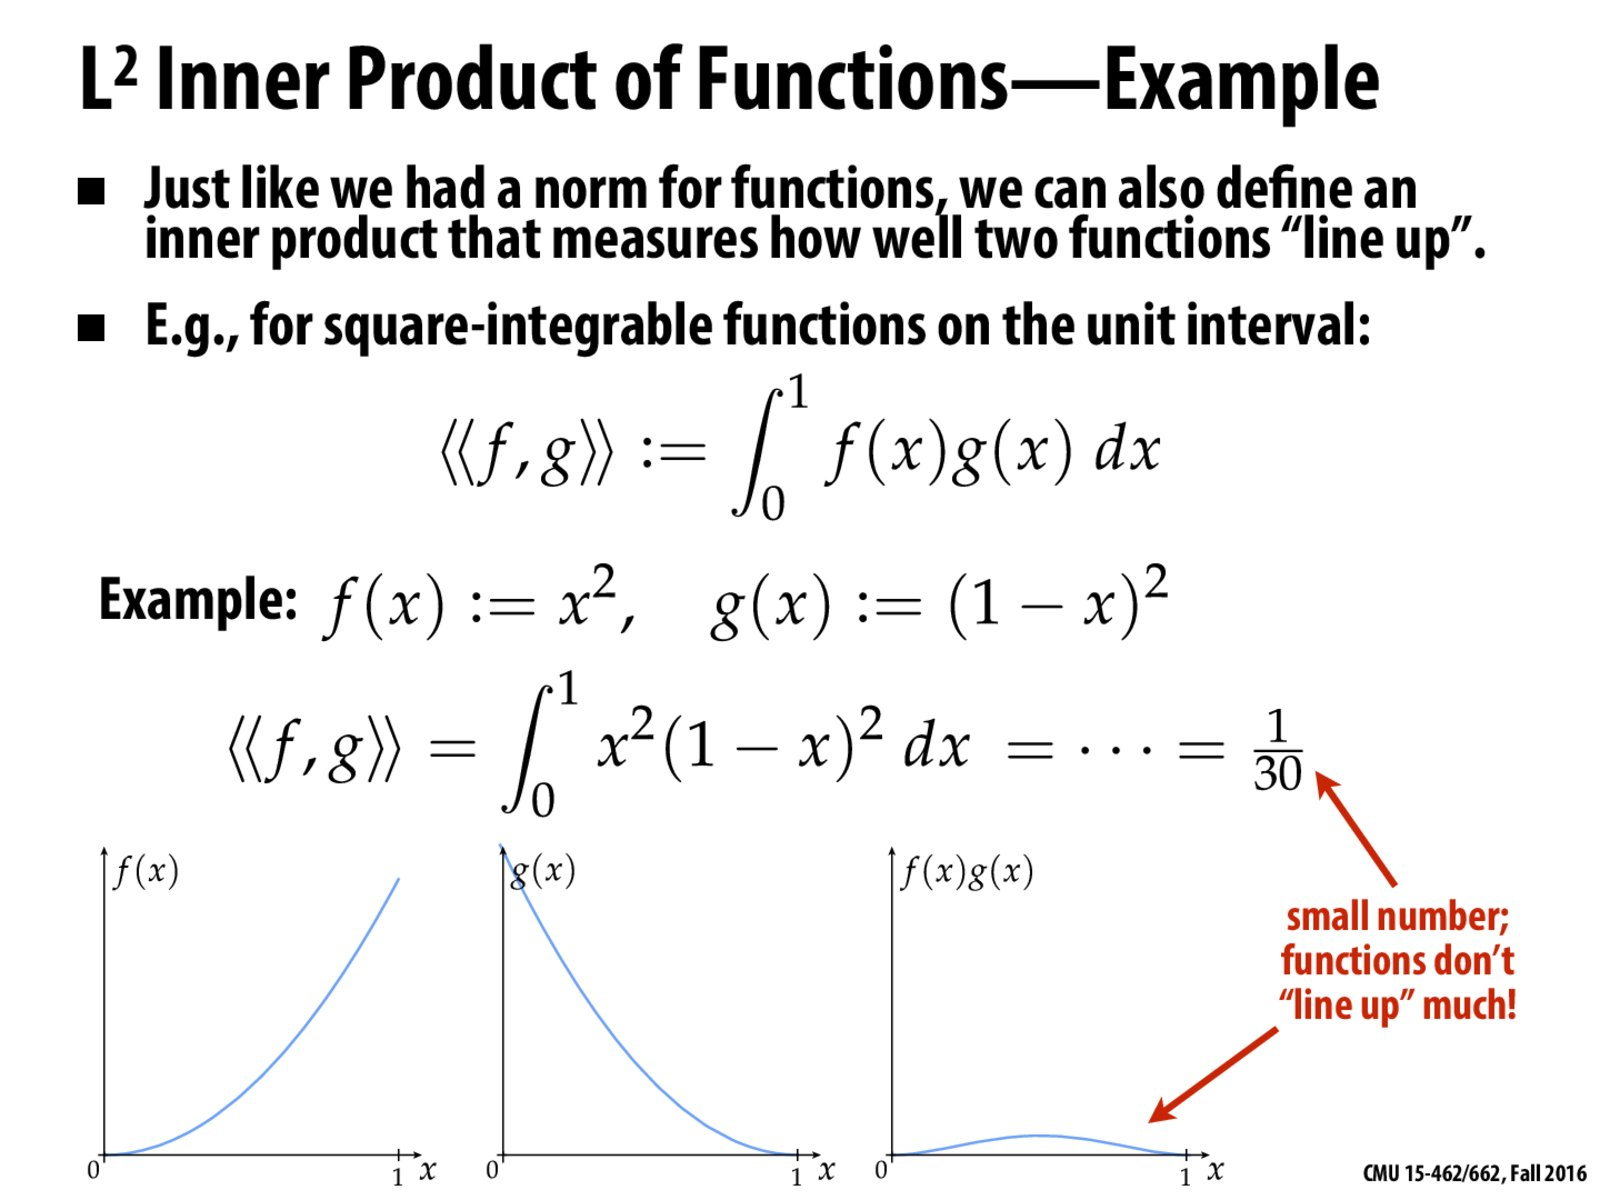
(image credit [Carnegie Mellon University](https://15462.courses.cs.cmu.edu/fall2016/lecture/linalg/slide_035))

Thankfully once we normalize the wavefunctions, the inner product is betwenn $-1$ and $1$, making it an extremely useful metric in determining how much two functions align. 

**Your task:**
1. Implement an inner product.
2. Normalize your trial wavefunctions.

In [ ]:
def inner(psi, phi, w):
    # set our initial value
    total = 0 
    for i in # how many points will we have in 
        total += # add one iteration of the sum approcimation above to the total
    return total

def normalize(psi, w):
    return psi / np.sqrt(inner(psi, psi, w))

phi_1n = normalize(phi_1, w)
phi_2n = normalize(phi_2, w)

#### Part D - Finite Difference Approximation

The kinetic energy operator depends on the second derivative.
On a grid, derivatives must be approximated numerically.

We use the centered finite-difference approximation

$$
\psi''(x_i)
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2}.
$$

**Your task:** Implement this operator. Take the second derivative of $sin(x)$ and plot it against $sin(x)$. How should these plots compare to each other. For such a simple diagnostic plot where units and axes don't have much meaning you can omit some titles, just make sure the shapes make sense. 

In [ ]:
def second_derivative(psi, dx):

    d2psi = np.zeros_like(psi)

    for i in range(1, len(psi)-1):
        d2psi[i] = # use the formula above to approximate the derivative

    return d2psi

#### Part E - Constructing the Laplacian Matrix

Up to this point, the second derivative has been implemented as a *procedure*
that takes one wavefunction and produces another. Our next goal is to represent
this same operation as a **matrix**.

---

##### From operators to matrices

Recall that our wavefunction is stored as a vector

$$
\psi =
\begin{pmatrix}
\psi_1 \\
\psi_2 \\
\psi_3 \\
\vdots \\
\psi_n
\end{pmatrix},
$$

where each entry represents the value of the wavefunction at one grid point.

A matrix acts on this vector by forming weighted sums of its entries.
For example, multiplying by a matrix $A$ produces

$$
(A\psi)_i =
A_{i1}\psi_1 +
A_{i2}\psi_2 +
\cdots +
A_{in}\psi_n.
$$

Each **row** of the matrix determines how the new value at position $i$
is computed from nearby values of the wavefunction.

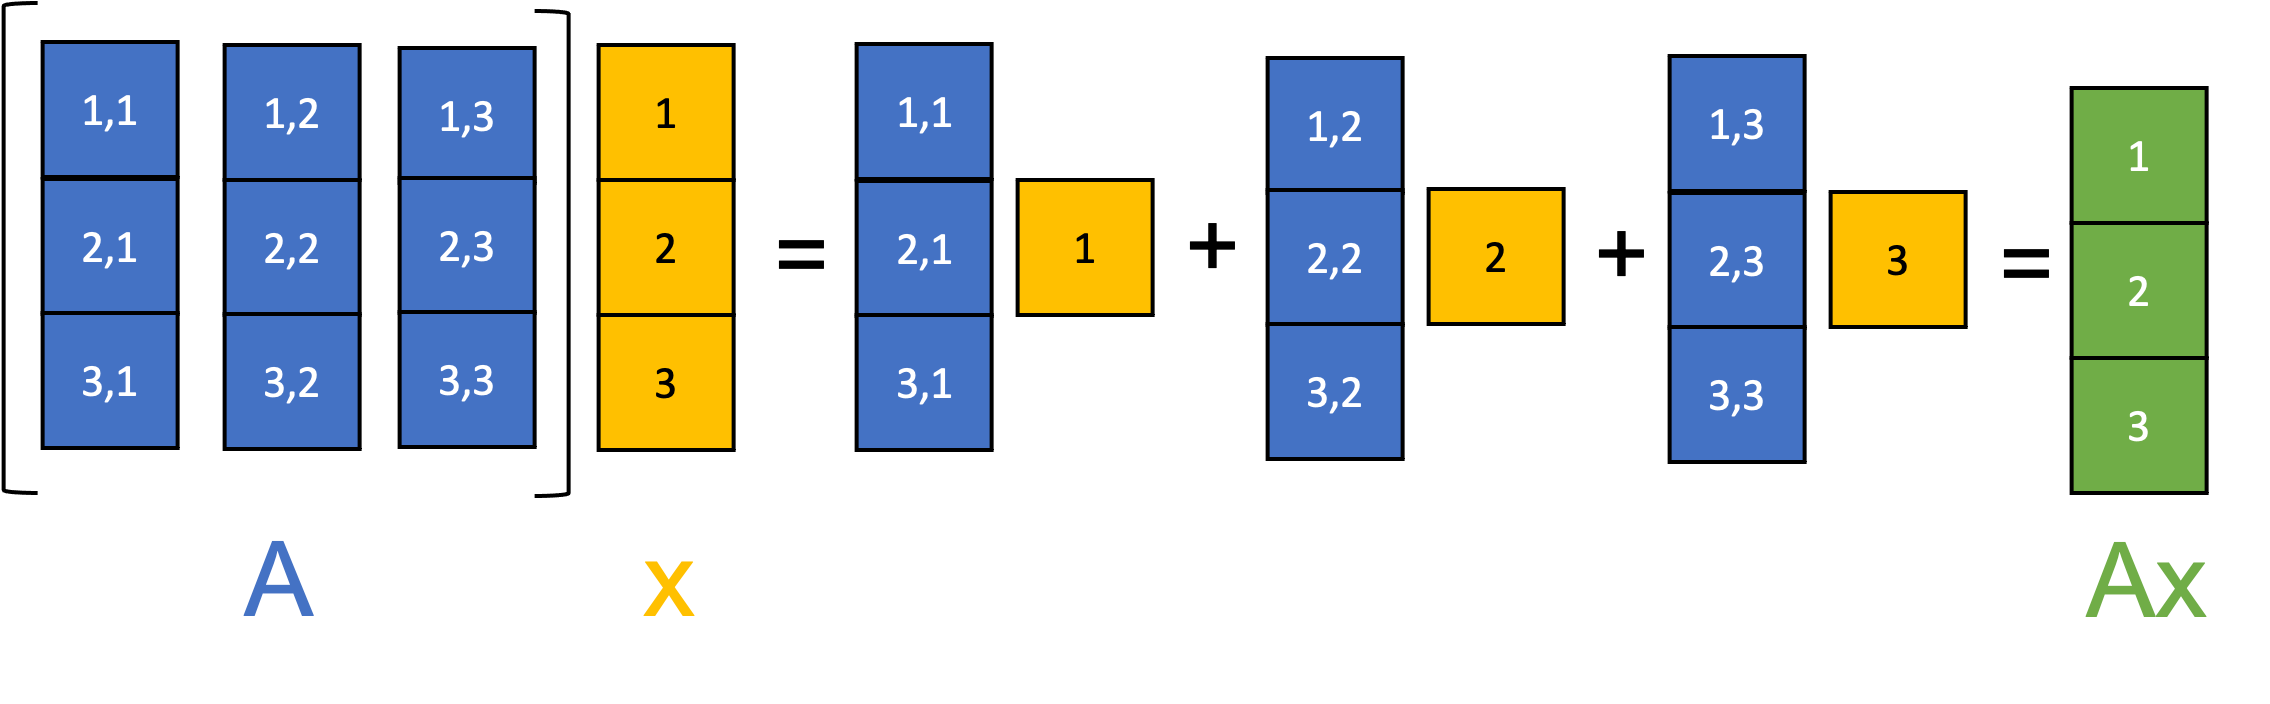
(image credit: [Matthew N. Bernstein *Matrix-vector multiplication*](https://mbernste.github.io/posts/matrix_vector_mult/))

---

##### Locality of the second derivative

From Part D, the finite–difference approximation gives

$$
\psi''(x_i)
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2}.
$$

Notice that the curvature at point $i$ depends only on  
- the value at $i$  
- the neighbor to the left  
- the neighbor to the right  

No distant points appear.

This assumption — that derivatives depend only on nearby points —
is called a **local approximation**.

---

##### What this means for the matrix

Because only neighboring values contribute, the matrix representing
the second derivative must look like

$$
\frac{1}{\Delta x^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & \cdots \\
1 & -2 & 1 & 0 & \cdots \\
0 & 1 & -2 & 1 & \cdots \\
0 & 0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

Each row contains nonzero entries only:

- on the diagonal
- one position above
- one position below

A matrix with this structure is called **tridiagonal**.

This structure is not accidental — it directly reflects the fact that
kinetic energy couples only neighboring regions of space.

---

### How we construct the matrix

Instead of writing this matrix by hand, we build it automatically.

We apply the derivative operator to each **basis vector**

$$
e_j =
\begin{pmatrix}
0 \\
\vdots \\
1 \\
\vdots \\
0
\end{pmatrix},
$$

which represents a wavefunction that is nonzero at only one grid point.

The result tells us exactly how the operator fills column $j$
of the matrix.

---

**Your task:**  
Construct the Laplacian matrix by applying `second_derivative`
to every basis vector. You are also free to construct an $n \times n$ matrix with $-2$ on the main diagonal an $1$ on the upper and lower diagonals and scale it, but I suspect this indexing is a bit trickier than slicing out a column of the matrix. 

In [ ]:
Lap = np.zeros((n, n)) # this creates an n by n matrix of zeros

for j in range(n):

    # basis vector localized at grid point j
    e_j = np.zeros(n)
    e_j[j] = 1.0

    # operator action becomes column j
    # apply the second_derivative function to e_j
    Lap[:, j] = ...

Lap

#### Part F - Assembling the Hamiltonian

The Hamiltonian represents the total energy of the system and is the sum of
the kinetic and potential energy operators,

$$
\hat H = \hat T + \hat V.
$$

In our discretized representation, both operators act on the wavefunction
stored as values on the spatial grid. The structure of their matrix
representations follows directly from how each operator acts physically.

---

##### Kinetic energy: coupling neighboring points

The kinetic energy operator is

$$
\hat T = -\frac{1}{2}\frac{d^2}{dx^2}.
$$

Using the finite–difference approximation developed earlier,

$$
\psi''(x_i)
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2},
$$

the kinetic energy at a point depends on the value of the wavefunction
at that point **and its immediate neighbors**.

This reflects the physical meaning of kinetic energy: it measures how
rapidly the wavefunction bends or changes in space. Determining this
curvature requires comparing nearby points, so the operator naturally
couples neighboring regions of space.

When written as a matrix, this locality produces nonzero elements only
on the diagonal and the two adjacent diagonals,

$$
T \sim
\begin{pmatrix}
\ast & \ast & 0 & \cdots \\
\ast & \ast & \ast & \cdots \\
0 & \ast & \ast & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix},
$$

which is why the kinetic energy matrix is **tridiagonal**.

---

##### Potential energy: purely local action

The harmonic potential is

$$
V(x)=\frac{1}{2}\omega^2 x^2.
$$

Unlike kinetic energy, the potential depends only on position.
Acting on a wavefunction gives

$$
(\hat V\psi)(x_i)=V(x_i)\psi(x_i).
$$

Each grid point is multiplied independently, and no neighboring values
appear. Because the operator does not mix spatial locations, its matrix
representation contains nonzero entries only along the diagonal,

$$
V =
\begin{pmatrix}
V(x_1) & 0 & 0 & \cdots \\
0 & V(x_2) & 0 & \cdots \\
0 & 0 & V(x_3) & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

---

##### The Hamiltonian matrix

The full Hamiltonian combines these two effects:

- kinetic energy spreads information between neighboring points,
- potential energy acts locally at each point.

Adding the matrices produces the numerical representation of the
Schrödinger equation,

$$
H = T + V.
$$

Diagonalizing this matrix will reveal the allowed vibrational energies
and their corresponding wavefunctions.

In [ ]:
# Kinetic energy matrix (from Part E)
T = -0.5 * Lap

omega = 1.0

# TODO: evaluate harmonic potential on the grid
V_x = ...

# TODO: convert potential into a diagonal matrix 
# HINT: check out the np.diag() method, this is a little less annoying than 
# looping through the matrix
V = ...

# Hamiltonian
H = T + V

#### Part G - Diagonalization and Energy Eigenstates

At this stage, the Schrödinger equation has been converted into a matrix
equation,

$$
H\psi = E\psi,
$$

where the Hamiltonian $H$ acts on vectors representing wavefunctions
defined on the spatial grid.

Solving this equation means finding special wavefunctions that are mapped
back onto themselves by the Hamiltonian, changing only by an overall
constant factor. These special functions are called **eigenfunctions**,
and the corresponding constants are the allowed **energy eigenvalues**.

---

##### What does diagonalization mean?

In general, when a matrix acts on a vector, it mixes components together.
If we write a wavefunction as

$$
\psi =
\begin{pmatrix}
\psi_1 \\
\psi_2 \\
\vdots
\end{pmatrix},
$$

then applying the Hamiltonian typically produces a new vector whose
entries depend on many components of the original one.

In other words, the Hamiltonian mixes basis functions.

Diagonalization finds a new coordinate system — a new **basis of
wavefunctions** — in which this mixing disappears.

Mathematically, diagonalization finds vectors satisfying

$$
H\psi_n = E_n \psi_n.
$$

If we think of $\psi_n$ as an arrow pointing somewhere in the space of all the wavefuncitons we could have, applying $H$ doesn't change where the vector points, it just scales the length of the arrow by some value $E_n$. When written in this new basis, the Hamiltonian takes the form

$$
H =
\begin{pmatrix}
E_0 & 0 & 0 & \cdots \\
0 & E_1 & 0 & \cdots \\
0 & 0 & E_2 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

Each basis vector evolves independently rather than interacting with
others.

This independence becomes especially important when we consider the
**time-dependent Schrödinger equation**

$$
i\frac{\partial \psi}{\partial t} = H\psi.
$$

Suppose the system begins in one of the eigenfunctions obtained from
diagonalization, so that

$$
H\psi_n = E_n \psi_n.
$$

Substituting this into the time-dependent Schrödinger equation gives

$$
i\frac{\partial \psi_n}{\partial t}
=
E_n \psi_n.
$$

This equation has the solution

$$
\psi_n(x,t)
=
\psi_n(x)\,e^{-iE_n t}.
$$

Notice what changes in time: only an overall complex phase factor.
The spatial function $\psi_n(x)$ itself remains unchanged.

Because measurable quantities depend on the probability density,

$$
|\psi_n(x,t)|^2 = |\psi_n(x)|^2,
$$

the observable shape of the wavefunction does not evolve in time.
States with this property are called **stationary states**.

Diagonalization therefore finds the special basis of wavefunctions whose
physical behavior is simplest: under time evolution, they do not change
shape, but only acquire a phase, which we can throw out when looking at the spatial distribution.

---

**Your task:**
1. Leave comments on the provided code explaining what each part does.
2. Run the provided code and see the eigenvectors of your Hamiltonian matrix!

In [ ]:
# hint: this is the important part
energies, eigenvectors = np.linalg.eigh(H)

num_states = 6
print("Energy eigenvalues:")
print(f"{'n':>3}  {'Energy':>12}")
for i in range(num_states):
    exact = (i + 0.5) * omega
    print(f"{i:>3}  {energies[i]:>12.6f}")

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
axes = axes.flatten()

V_scaled = 0.5 * omega**2 * x_array**2
V_plot = V_scaled / V_scaled.max()

for i in range(num_states):
    ax = axes[i]
    psi_n = eigenvectors[:, i]

    if psi_n[np.argmax(np.abs(psi_n))] < 0:
        psi_n = -psi_n

    ax.plot(x_array, psi_n, color='blue', label=r'$\psi_n(x)$')
    ax.fill_between(x_array, psi_n, alpha=0.15, color='blue')
    ax.plot(x_array, V_plot * np.max(np.abs(psi_n)), color='red',
            linestyle='--', alpha=0.4, label='$V(x)$ (scaled)')

    ax.set_title(f"$n = {i}$,  $E = {energies[i]:.3f}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$\\psi_n(x)$")
    ax.axhline(0, color='gray', linewidth=0.5)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Harmonic Oscillator Eigenstates from Numerical Diagonalization", fontsize=13)
plt.tight_layout()
plt.show()

### Question 1
`25 points` 

- C5.2: Explain how continuous quantum systems are represented numerically using spatial discretization and boundary conditions.
- C5.3: Relate the physical behavior of kinetic and potential energy operators to their matrix representations.
- C5.4: Interpret Hamiltonian diagonalization as a change of basis that reveals independent quantum states.
- C5.5: Connect Hamiltonian eigenfunctions to time evolution and explain why stationary states have time-independent probability densities.
- C5.6: Explain why representing quantum systems in the energy eigenbasis simplifies analysis and interpretation of dynamics.

a) Why is discretization necessary for solving the Schrödinger equation on a computer, and what physical assumption is introduced by restricting the system to a finite spatial region?

b) The kinetic energy matrix was tridiagonal, while the potential energy
matrix was diagonal. Explain how the physical action of each operator leads to these different matrix structures.

c) What does it mean for a wavefunction to be an eigenfunction of the Hamiltonian, and why does diagonalization eliminate mixing between states?

d) Using the time-dependent Schrödinger equation, explain why Hamiltonian eigenfunctions are called stationary states.

e) Any wavefunction can be written as a combination of energy
eigenfunctions. Why does expressing a quantum state in this basis simplify the
description of quantum motion and physical behavior?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="part2"></a>
## Part 2 — Rotational Motion of Molecules

In the previous section, we studied **vibrational motion**, where atoms move
toward and away from one another along a bond. By constructing and
diagonalizing the Hamiltonian, we discovered that molecular vibrations
possess discrete energy levels and stationary quantum states.

Vibration, however, is only one way a molecule can move.

Even when the distance between atoms remains fixed, a molecule can still
rotate in space. Rather than changing bond length, rotational motion
changes the **orientation** of the molecule while preserving its internal
structure. This type of motion is well described by the **rigid rotor
approximation**, in which the bond length is assumed to remain constant.

From a mathematical perspective, this introduces an important change.
In the vibrational problem, motion occurred along a line and the
wavefunction depended on position $x$. Rotational motion instead occurs
on the surface of a sphere, so the quantum state depends on angular
coordinates describing molecular orientation.

Despite this geometric difference, the strategy for solving the problem
remains the same:

1. describe the allowed motion,
2. construct the Hamiltonian operator,
3. represent it numerically,
4. diagonalize the Hamiltonian to obtain stationary states.

In this section, you will apply the same computational ideas developed
for vibrational motion to a new physical system. Along the way, an
important new feature will emerge: **degeneracy**, where multiple distinct
quantum states share the same energy due to the symmetry of rotational
motion.

### 2.1 — Classical Picture of Molecular Rotation

Before constructing a quantum mechanical description of rotational
motion, it is helpful to understand how rotation is described
classically.

Consider a diatomic molecule consisting of two atoms connected by a
bond. Even if the bond length remains fixed, the molecule can rotate
about its center of mass. During this motion, the atoms trace circular
paths while maintaining a constant separation.

In classical mechanics, the kinetic energy associated with rotational
motion is written as

$$
E_{\text{rot}} = \frac{L^2}{2I},
$$

where $L$ is the angular momentum and $I$ is the **moment of inertia**.
The moment of inertia measures how mass is distributed relative to the
axis of rotation and determines how difficult it is to rotate an object.

For a diatomic molecule rotating about its center of mass, the moment of
inertia is

$$
I = \mu r_e^2,
$$

where

- $\mu$ is the **reduced mass**
$$
\mu = \frac{m_1 m_2}{m_1 + m_2},
$$
- $r_e$ is the equilibrium bond length.

This result shows that rotational motion depends directly on molecular
structure. Heavier atoms or longer bond lengths increase the moment of
inertia, which lowers the rotational energy spacing. This relationship
will later allow rotational spectra to reveal bond lengths
experimentally.

Unlike vibrational motion, no restoring force is required for rotation.
The molecule moves freely while constrained only by its fixed bond
length. As we will see, this geometric constraint alone is sufficient to
produce quantized energy levels in quantum mechanics.

### Coding Activity 2 — Moment of Inertia
`10 points`

In this exercise, you will compute the moment of inertia for several
diatomic molecules and explore how molecular structure influences
rotational motion.

Complete the function below.

Use your function to compute the moment of inertia for at least two
diatomic molecules (for example $\text{HCl}$, $\text{CO}$, or $\text{N}_2$).

Compare your results and answer the question below.

In [ ]:
# atomic masses in atomic mass units (amu)
amu_to_kg = 1.66054e-27

def moment_of_inertia(m1, m2, r):
    """
    Compute the moment of inertia of a diatomic molecule.

    Parameters
    ----------
    m1, m2 : float
        Atomic masses (amu)
    r : float
        Bond length (meters)

    Returns
    -------
    I : float
        Moment of inertia (kg m^2)
    """
    
    # TODO: compute reduced mass
    mu = ...

    # TODO: compute moment of inertia
    I = ...

    # What should our function return?
    return None

### Question 2
`10 points` 

- C5.7: Predict qualitative trends in rotational energy spacing from
molecular properties.

How does increasing bond length or atomic mass affect the moment of
inertia, and what do you expect this to do to rotational energy level
spacing?

---

*Your answer here (`double click me!`):*

### 2.2 — Describing Rotation with Spherical Coordinates

In the vibrational problem, molecular motion occurred along a single
direction. The wavefunction depended on position $x$, and the system was
naturally described using Cartesian coordinates.

Rotational motion is fundamentally different.

When a diatomic molecule rotates while maintaining a fixed bond length,
the atoms do not move freely through space. Instead, the molecule’s
**orientation** changes while the distance between the atoms remains
constant. This motion is constrained to the surface of a sphere centered
at the molecule’s center of mass.

Because of this constraint, Cartesian coordinates are no longer the most
useful description of the system. Rather than asking *where* the atoms
are located, it is more natural to describe *how the molecule is
oriented* in space.

This orientation is specified using **spherical coordinates**

$$
(r,\theta,\phi),
$$

where

- $r$ measures distance from the center,
- $\theta$ is the polar angle,
- $\phi$ is the azimuthal angle.

For a rigid rotor, the bond length does not change, so

$$
r = r_e,
$$

and radial motion is removed from the problem. The quantum state
therefore depends only on angular variables,

$$
\psi = \psi(\theta,\phi).
$$

In the next activity, you will use an interactive visualization to see
how changing $(\theta,\phi)$ changes the **orientation** of the molecule
without changing its bond length.

In [ ]:
# Use the provided helper to explore spherical coordinates interactively
interactive_spherical_plot()

### Question 3
`10 points`

- P5.4 Use spherical coordinates to describe molecular orientation in three dimensions.

Using your observations from the interactive plot, explain why fixing the
bond length removes radial motion from the Schrödinger equation and
leaves only angular degrees of freedom.

Your answer should explicitly reference what changing each of
$r$, $\theta$, and $\phi$ does to the molecule.

---

*Your answer here (`double click me!`):*

### 2.3 — The Particle on a Ring

Before studying full three-dimensional molecular rotation, we begin with a simpler model that captures the essential physics of rotational motion while remaining computationally accessible.

Consider a particle constrained to move along a circular path of fixed radius. The particle cannot move closer to or farther from the center; it may only change its angular position around the circle. This system is known as the particle on a ring, or planar rotor.

Because the distance from the center is fixed, the particle’s position is completely described by a single coordinate: the angle $\phi$.

The wavefunction therefore takes the form

$$
\psi(\phi)
$$

which describes how the probability amplitude varies as the particle moves around the ring.

Periodicity of Rotational Motion

Unlike the vibrational systems studied previously, angular motion has no physical boundaries. Rotating through an angle of $2\pi$ returns the particle to the same physical location. The wavefunction must therefore satisfy a periodic boundary condition

$$
\psi(\phi + 2 \pi) = \psi(\phi).
$$

This condition fundamentally changes how derivatives and operators behave. Instead of vanishing at endpoints, the wavefunction must connect smoothly across them. In a numerical representation, the angular grid therefore wraps around: the point at $\phi=0$ is a neighbor of the point near $\phi=2\pi$.


### Coding Activity 4
`25 points`

In the following exercise, you will:

1. represent angular wavefunctions on a periodic grid,

2. construct the finite-difference operator describing angular curvature,

3. diagonalize this operator to obtain rotational eigenfunctions.

This procedure mirrors the strategy used for vibrational motion, but now incorporates the geometric constraint of periodic rotation.

Once these rotational states are obtained numerically, we will connect them to the quantum mechanical Hamiltonian for rotational motion and interpret their physical meaning.

---

#### 2.3A - Waves on a Ring
The first thing we should do is visualize what a wavefunction on a rind would look like in the first place. Define `phi` on $[0, 2\pi)$. We can exclude the right endpoint using `endpoint=False` in `np.linspace`. After you have this choose some function that follows $\psi(\phi + 2 \pi) = \psi(\phi)$ and call it `psi`. Pay attention to the example below to see how to plot 3D parametric curves. 

In [ ]:
%matplotlib widget

# Make an array of evenly spaced points between 0 and 2pi
phi = ...

# write some wavefunction, trig functions work and are easy! Chose a frequency > 1 that fits our condition
psi = ...

# identities for polar -> Cartesian coordinates
x = np.sin(phi)
y = np.cos(phi)

plt.close('all')
ax = plt.figure().add_subplot(projection='3d')
ax.plot(x, y, 0.0, color='red', linestyle='--')
ax.plot(x, y, psi, color='b')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$\psi$')
plt.show()

#### 2.3b — The second derivative in a periodic coordinate

In the vibrational section, kinetic energy depended on the second
derivative of the wavefunction with respect to position, and we
approximated this numerically using nearby grid points.

Rotational motion follows the same principle: rotational kinetic energy
depends on the **local curvature** of the wavefunction as the molecule
rotates.

The key difference is geometric.

Angular coordinates are **periodic**. Rotating past $\phi=2\pi$ brings us
back to $\phi=0$, so the “neighbors” of the first grid point include the
last grid point. This wrap-around behavior is what distinguishes
rotation from linear motion, and it will directly determine the
structure of the rotational Hamiltonian matrix.


In this activity you will build a numerical approximation to the angular
second derivative and convert it into a matrix representation of the
operator.

- P5.1: Construct numerical operators representing quantum mechanical observables.

On the angular grid, we approximate curvature using the same finite
difference form as before:

$$
\frac{d^2\psi}{d\phi^2}(\phi_i)
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta\phi^2}.
$$

The difference is that the indices wrap around:

- the “left neighbor” of $i=0$ is the last grid point,
- the “right neighbor” of the last grid point is $i=0$.

You will implement this numerically in the next step.

---

Write a function that returns the finite-difference approximation to
$\psi''(\phi)$ for a periodic wavefunction stored on the grid.

**Hint:** In Python, the modulo operator `%` is often used to wrap
indices back into the allowed range. For example, `i % N` always lies
between `0` and `N-1`. Use this idea to handle the right neighbor near
the boundary.

Do not hard-code special cases for the endpoints: your loop should work
for all `i` using the same logic.

In [ ]:
def second_derivative_periodic(psi, dphi):
    """
    Compute the second derivative using periodic boundary conditions.

    Parameters
    ----------
    psi : np.ndarray
        Wavefunction values on a periodic angular grid.
    dphi : float
        Grid spacing.

    Returns
    -------
    d2psi : np.ndarray
        Approximation to d^2 psi / dphi^2 at each grid point.
    """
    N = len(psi)
    d2psi = np.zeros_like(psi)

    # YOUR CODE HERE
    for i in range(N):

        # left neighbor index (wrap-around should happen automatically if done correctly)
        left = ...

        # right neighbor index (wrap-around needed near the boundary)
        right = ...

        d2psi[i] = (right - 2*psi[i] + left) / dphi**2

    return d2psi
    
d2psi = second_derivative_periodic(psi, phi[1] - phi[0])

# lets make a quick plot to see if it makes sense (what is d^2/dx^2 sin(x)?)
plt.plot(phi, psi, color='blue')
plt.plot(phi, d2psi, color='red')


If your implementation is correct, your output should be smooth and periodic. If you see large spikes or discontinuities near the boundary, that is a strong sign that periodic indexing is not being handled correctly.

#### 2.3C — From a procedure to a matrix

In Part 1, we built an operator matrix by applying the operator to basis
vectors. We will do the same here.

Each basis vector $e_j$ represents a wavefunction that is nonzero at
only one grid point. Applying the second derivative to $e_j$ produces
column $j$ of the operator matrix.

Build the angular Laplacian matrix below.

In [ ]:
N = len(phi)
Lap_phi = np.zeros((N, N))

for j in range(N):
    e = np.zeros(N)
    # make the jth value of e eqau to 1 and then call second_dersecond_derivative_periodic on e with dphi
    Lap_phi[:, j] = second_derivative_periodic(e, dphi)

Lap_phi

#### 2.3D — What structure do you see?

Inspect `Lap_phi`.

You should observe:

- nonzero diagonal elements,
- nonzero elements immediately above and below the diagonal,
- additional nonzero entries connecting the upper-right and lower-left corners.

These corner entries represent the fact that the first and last grid points are neighbors, which is the numerical signature of rotational periodicity.

#### 2.3E — Rotational Eigenfunctions and Degeneracy

Up to this point, you have constructed the angular Laplacian operator, which measures how rapidly a wavefunction curves as the particle moves around the ring.

For rotational motion, kinetic energy arises entirely from this angular curvature. The planar rotor Hamiltonian is therefore proportional to the angular Laplacian,

$$
\hat H =
-\frac{1}{2I}\frac{d^2}{d\phi^2},
$$

where $I$ is the moment of inertia.

Because multiplying an operator by a constant does not change its eigenfunctions, we may study the structure of rotational states by diagonalizing the Laplacian itself.

You're probably wondering how we get these eigenfunctions. Numerically determinig these values is tricky, doing it in a smart way is evern trickier! Thankfully the good people of NumPy have given us [a function](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html) that quickly finds the eigenvalues and eigenvectors of matricies like our. For now well assume $I = 1/2$ to simplify our equations. 

Find the values of the eigenvalues and eigenvectors of `lap_phi` and print them out below. After you complete this make a plot (with axis labels and a plot title) of the second and third eigenvectors of our matrix vs $\phi$.  

In [ ]:
# use the numpy.lingalg.eigh function to find the eigenvalues and vectors.
# the vectors will return as a matrix, where each collumn is an eigenvalue

# plot the second and third eigenfunctions. 
# If you dont see a clear relationship between the two check that your indicies start in the right place.



### 2.4 — Rotational Motion in Three Dimensions

The particle on a ring allowed us to study rotational motion using a single angular coordinate. Real molecules, however, are not restricted to a plane. A freely rotating molecule may orient itself in any direction in space.

To describe this motion, we must move from rotation on a circle to rotation on the surface of a sphere.

#### Rotation on a Sphere

When the bond length of a molecule is fixed, its orientation relative to space is completely specified by two angles:

 - the polar angle $\theta$, which measures inclination,

 - the azimuthal angle $\phi$, which measures rotation about an axis.

The rotational wavefunction therefore becomes

$$
\psi(\theta, \phi),
$$

representing a probability amplitude distributed over the surface of a sphere.

In principle, rotational kinetic energy depends on how rapidly this wavefunction changes as we move across the curved surface. Mathematically, this requires taking derivatives along angular directions rather than along straight spatial coordinates.

The derivative operator on a sphere is considerably more complicated than the one-dimensional derivatives used previously, and we will not derive it here. The important idea is conceptual, rotational kinetic energy measures curvature of the wavefunction over the surface of a sphere.

#### Angular Momentum and the Rigid Rotor

In quantum mechanics, rotational motion is governed by angular momentum.
The rigid rotor Hamiltonian takes the form

$$
\hat{H} = \frac{\hat{L}}{2I}
$$

where $\hat L^2$ measures total angular momentum.

Solving this problem reveals a set of allowed rotational states labeled
by two quantum numbers:

 - $J$ — the total angular momentum quantum number,
 - $m$ — the projection of angular momentum along a chosen axis.

#### Meaning of the Quantum Numbers

The quantum number $J$ determines the overall amount of rotational motion. Larger values of $J$ correspond to wavefunctions that vary more rapidly across the sphere and therefore possess greater rotational energy.

For each value of $J$, the quantum number $m$ may take values

$$
m = -J, -J + 1, \dots, J
$$

These different values of $m$ correspond to distinct rotational states that share the same total angular momentum but differ in how the rotation is oriented relative to space.

As a result, each energy level associated with $J$ contains multiple states, a phenomenon known as degeneracy.

#### Visualizing Rigid Rotor Wavefunctions

The function `plot_rigid_rotor` displays rigid-rotor wavefunctions on the surface of a sphere. In addition to amplitude, it also displays the phase of the wavefunction.

In [ ]:
plot_rigid_rotor(J=..., m=...)
plot_rigid_rotor(J=..., m=...)

### Question 4
`15 points`

a) How does the phase change as you move around the sphere when you compare opposite $m$ values?

b) Why does rotational motion lead to periodic wavefunctions, and how does this periodicity influence the allowed rotational states obtained through diagonalization?

c) When comparing rigid rotor states with the same value of $J$ but different values of $m$ (not necessarily negative), what features of the wavefunction change and what features remain the same?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="part3"></a>
## Part 3 - Reaction Thermodynamics from Quantum Chemistry

### 3.1 Why Do We Need Thermodynamic Corrections?

Up to this point in the lab, we have studied vibrational and rotational motion as quantum mechanical models. These were not abstract exercises — they describe real molecular motion that contributes directly to thermodynamic quantities.

A single electronic energy obtained from quantum chemistry represents only the electronic ground state energy of a molecule. Real molecules also possess:

 - vibrational motion,

 - rotational motion,

 - translational motion.

Thermodynamic observables such as enthalpy and Gibbs free energy therefore require contributions beyond electronic structure alone.

A standard computational chemistry workflow addresses this through two calculations:

1. Geometry Optimization (OPT)
    - Finds the equilibrium molecular structure.
2. Frequency Calculation (FREQ)
    - Computes vibrational modes and thermodynamic corrections using the RRHO approximation.

In this section, you will apply this workflow to a chemically meaningful reaction and connect molecular motion to reaction thermodynamics.

### 3.2 Chemical System: A Diels–Alder Reaction

We examine the reaction

<div style="text-align: center;">
      <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQZPg2KUKbOOjXwX135DpBgBuPAeW9W4kYheQ&s">
</div>

(image credit: [Anton Manakhov *Towards the thermally reversible adhesion between metallic and polymeric surfaces functionalized by atmospheric plasma polymerization and gas phase reactions*](https://www.researchgate.net/publication/267041444_Towards_the_thermally_reversible_adhesion_between_metallic_and_polymeric_surfaces_functionalized_by_atmospheric_plasma_polymerization_and_gas_phase_reactions_Manakhov_Anton_-_Namur_Presses_universitai))


This reaction forms new σ bonds through orbital reorganization and provides a realistic example where entropy and vibrational effects strongly influence spontaneity.

### Coding Activity 5 - Reaction Thermodynamics 
`25 points`

 - C5.1: Explain how vibrational and rotational motion arise from quantum mechanical operators and describe how these motions produce discrete molecular energy levels.
 - C5.2: Interpret molecular Hamiltonians as operators whose diagonalization produces physically meaningful molecular states and energies.
- C5.3: Relate vibrational and rotational energy levels to thermodynamic quantities such as enthalpy and Gibbs free energy through the RRHO approximation.
- C5.4: Apply the OPT + FREQ workflow to obtain equilibrium geometries, vibrational frequencies, and reaction thermodynamic quantities.
- P5.1: Translate differential operators and physical models into executable numerical representations using arrays and matrices.
- P5.2: Represent continuous wavefunctions on computational grids and interpret vectors as numerical function representations.
- P5.3: Use matrix construction and diagonalization to solve physical eigenvalue problems.

#### 3.2A - Building Molcules from SMILES
Chemists often describe molecules using SMILES strings, which encode bonding connectivity.

Create SMILES strings for:

 - ethene
 - butadiene
 - cyclohexene

In [ ]:
ethene = ...
butadiene = ...
cyclohexene = ...

#### 3.2B - Visual Inspection
Use the `show_molecule(smiles)` helper function to:
 - Visualize each molecule.
 - Confim bonding connectivity matches chemical expectations. 

#### 3.2C — Geometry Optimization
Before thermodynamic quantities can be computed, each molecule must be placed at its equilibrium geometry.

A geometry optimization adjusts atomic positions until the forces acting on all nuclei vanish. At this point, the molecule sits at a minimum on its potential energy surface, meaning small displacements correspond to physically meaningful vibrational motion.

Because vibrational frequencies describe oscillations *about equilibrium*, all frequency and thermodynamic calculations must begin from an optimized structure.

Quantum chemistry calculations produce detailed results such as optimized geometries, energies, and vibrational data. These results are written to output files.

Saving a unique output file for each molecule allows calculations to be inspected later, reused without recomputation, and checked for successful convergence. For this reason, each molecule in the reaction is assigned its own output file before optimization.

**Your Task**

Run geometry optimizations for all reaction species using the workflow below.
Each calculation should:

1. Set a unique output file.

2. Create a Psi4 molecule.

3. Optimize the geometry.

4. Store the optimized energy and wavefunction for later use.

In [ ]:
psi4.set_memory('1 GB')
my_theory = 'SCF/STO-3G'

# here is an example for ethene, reproduce this for butadiene and cyclohexane below
psi4.set_output_file('ethene.dat', False)
p4ethene = create_psi4_molecule(ethene)
ethene_energy, ethene_wfn = psi4.optimize(
    my_theory,
    return_wfn=True,
    molecule=p4ethene
)

In [ ]:
# YOUR CODE HERE: OPTIMIZE THE OTHER MOLECULES

In [ ]:
# YOUR CODE HERE: OPTIMIZE THE OTHER MOLECULES

#### 3.2D — Electronic Reaction Energy

After completing the geometry optimizations, Psi4 has returned the optimized electronic energy for each molecule. These energies describe the stability of the reactants and products at the electronic level and allow us to estimate the reaction energy before including thermodynamic corrections.

For the reaction

$$
\text{butadiene} + \text{ethene} -> \text{cyclohexane}
$$

the electronic reaction energy is computed as the difference between product and reactant energies,

$$
\Delta E_\text{elec} = E_\text{products} - E_\text{reactants}.
$$

The sign of this quantity indicates whether the products are electronically more or less stable than the reactants. A negative value suggests stabilization upon reaction, while a positive value indicates an electronically uphill process.

Psi4 reports energies in Hartree, the natural unit of energy in quantum mechanics. While convenient for electronic structure calculations, Hartree units are not typically used when discussing chemical reactions. To interpret the reaction energy in chemically meaningful terms, we convert to kilojoules per mole using

$$
1 \ \text{Hartree} = 2625.5 \ \text{kJ mol}^{-1}.
$$

The sign of this quantity indicates whether the products are electronically more or less stable than the reactants. A negative value suggests stabilization upon reaction, while a positive value indicates an electronically uphill process.

Calcualte the change in electronic energy and convert to kilojoules per mole.

In [ ]:
reaction_energy = ...
rxn_e_kj_mol = ...
print(f"reaction (electronic) energy: {rxn_e_kj_mol:.1f} kJ/mol")

#### 3.2E — Frequency Calculations and Thermodynamic Corrections

The electronic reaction energy calculated above includes only the energy of the electrons at the optimized molecular geometries. However, real thermodynamic quantities also include contributions from molecular motion.

A frequency calculation evaluates how the energy changes when atoms are slightly displaced from equilibrium. Mathematically, this corresponds to analyzing the curvature of the potential energy surface near the optimized structure. The resulting vibrational modes are treated using the rigid-rotor harmonic-oscillator approximation, allowing thermodynamic quantities such as enthalpy and Gibbs free energy to be computed.

Because Psi4 automatically updates molecular coordinates after a successful geometry optimization, the optimized structures are already stored in memory. This means the frequency calculation can be performed directly without repeating the optimization step.

Run frequency calculations for each molecule and extract the thermodynamic quantities reported by Psi4. With these quantities calculate and report the change in Gibb's free energy for the reaction. 

In [ ]:
# here is example for ethene
psi4.set_output_file('ethene.dat', False)

ethene_energy, ethene_wfn = psi4.frequency(
    my_theory,
    return_wfn=True,
    molecule=p4ethene
)

ethene_enthalpy = psi4.variable('enthalpy')
ethene_gibbs = psi4.variable('gibbs free energy')

print(f"{ethene_enthalpy:.2f} , {ethene_gibbs:.2f}")

In [ ]:
# YOUR CODE HERE: calculate for the other two molecules

In [ ]:
# YOUR CODE HERE: calculate for the other two molecules

In [ ]:
# YOUR CODE HERE: calculate delta G 

### Question 5

`25 points` 

a) Why must a frequency calculation be performed at an optimized geometry rather than an arbitrary molecular structure?

b) What physical information about molecular motion is obtained from a frequency calculation?

c) What does a vibrational frequency physically represent for a molecule near equilibrium?

d) Why do thermodynamic quantities such as enthalpy and Gibbs free energy differ from the electronic energy alone?

e) How do vibrational motions contribute to the thermodynamic stability of a molecule?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="part4"></a>
## Part 4 — Infrared Spectroscopy

Vibrational motion is not only a theoretical construct — it produces directly observable experimental signatures. One of the most important of these is infrared (IR) spectroscopy.

Each vibrational mode computed in the frequency calculation corresponds to a possible transition between vibrational energy levels. In the harmonic oscillator model, these transitions occur at well-defined frequencies and would appear as sharp absorption lines.

As discussed in the thermodynamics section, vibrational modes are defined as small oscillations about an equilibrium structure. For this reason, IR spectral predictions require the same OPT + FREQ workflow used previously. If frequencies were computed at a non-optimized geometry, the resulting vibrational modes would not correspond to physically meaningful motions, and the simulated spectrum would be unreliable.

In the ideal harmonic approximation, each vibrational transition would appear as a discrete line. Real experimental spectra, however, show broadened peaks rather than infinitely sharp lines. This broadening arises from:

 - anharmonic effects,

 - thermal population of excited vibrational states,

 - environmental interactions.

While fully capturing these effects requires more advanced methods, a useful approximation can be obtained by applying Gaussian broadening to the discrete vibrational line spectrum.

In this section, you will construct simulated IR spectra from the frequency calculations performed earlier. This connects the vibrational eigenvalues obtained from diagonalization to experimentally measurable absorption features.

### Coding Activity 6 — Constructing Simulated IR Spectra
`15 points`

 - C5.4: Apply the OPT + FREQ workflow to obtain equilibrium geometries, vibrational frequencies, and reaction thermodynamic quantities.
 - C5.5: Connect computed vibrational frequencies and IR intensities to experimentally observable infrared spectra.
 - P5.4: Extract, transform, and interpret scientific results produced by computational chemistry software.

Each psi4.wavefunction object produced during the frequency calculation contains a dictionary called frequency_analysis. This dictionary stores vibrational frequencies and their corresponding IR intensities.

Your goal is to extract this information and use it to generate a simulated spectrum for each molecule, then use the `plot_spectrum` function to visuaulze the IR modes. 

In [ ]:
ethene_freq_dict = ethene_wfn.frequency_analysis

ethene_frequencies = ethene_freq_dict['omega'].data
ethene_intensities = ethene_freq_dict['IR_intensity'].data

# YOUR CODE HERE: use plot_spectrum

In [ ]:
# YOUR CODE HERE: obtain and plot frequencies for the other two molecules

In [ ]:
# YOUR CODE HERE: obtain and plot frequencies for the other two molecules

### Question 6
`15 points`

a) What physical molecular motion is responsible for absorption in an IR spectrum?

b) Why do simulated spectra apply Gaussian broadening instead of plotting only discrete frequency lines?

c) How does the simulated IR spectrum connect the quantum mechanical vibrational model developed earlier to an experimentally measurable quantity?

---

*Your answer here (`double click me!`):*

<br></br>

<a id="reflection"></a>
## Reflection 
### Question 7
`20 points`


a) Throughout this assignment, wavefunctions were represented numerically and operators were constructed as matrices. How did this computational framework allow you to solve different quantum mechanical problems using the same underlying approach?

b) Explain how the quantum models of vibrational and rotational motion developed earlier in the lab contribute to thermodynamic quantities such as enthalpy and Gibbs free energy.

c) How does diagonalization connect microscopic molecular motion to experimentally observable quantities such as reaction energies or IR spectra?

d) In this assignment, theoretical models were used to predict measurable chemical behavior. Give one example where a computational result you obtained corresponds directly to an experimental observable, and explain the connection.

---

*Your answer here (`double click me!`):*